In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
results = pd.read_csv("../data/results.csv")

In [3]:
results.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


In [4]:
results.info()

<class 'pandas.DataFrame'>
RangeIndex: 49505 entries, 0 to 49504
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        49505 non-null  str    
 1   home_team   49505 non-null  str    
 2   away_team   49505 non-null  str    
 3   home_score  49501 non-null  float64
 4   away_score  49501 non-null  float64
 5   tournament  49505 non-null  str    
 6   city        49505 non-null  str    
 7   country     49505 non-null  str    
 8   neutral     49505 non-null  bool   
dtypes: bool(1), float64(2), str(6)
memory usage: 3.1 MB


In [5]:
results.shape

(49505, 9)

In [6]:
results.isnull().sum()

date          0
home_team     0
away_team     0
home_score    4
away_score    4
tournament    0
city          0
country       0
neutral       0
dtype: int64

In [7]:
results.duplicated().sum()

np.int64(0)

### Initial Data Inspection
The dataset contains **49,505 rows** and **9 columns**.

There are no duplicates present in the dataset.   
The columns seem promising and there are only 8 total null values in the home_score and away_score columns which are upcoming matches that haven't been played yet.   
We will have to covert date as it is in string form.   
Other than that the dataset is clean.

In [8]:
results[['home_score', 'away_score']].describe()

,home_score,away_score
count,49501.000000,49501.000000
mean,1.757197,1.181936
std,1.773821,1.401655
min,0.000000,0.000000
25%,1.000000,0.000000
50%,1.000000,1.000000
75%,2.000000,2.000000
max,31.000000,21.000000


In [9]:
results['home_score'].value_counts().head(10)

home_score
1.0    14564
0.0    11930
2.0    10835
3.0     5824
4.0     3032
5.0     1489
6.0      793
7.0      432
8.0      233
9.0      147
Name: count, dtype: int64

In [10]:
results[results['home_score'].isnull()]

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
49501,2026-07-09,France,Morocco,NaN,NaN,FIFA World Cup,Foxborough,United States,True
49502,2026-07-10,Spain,Belgium,NaN,NaN,FIFA World Cup,Inglewood,United States,True
49503,2026-07-11,Norway,England,NaN,NaN,FIFA World Cup,Miami Gardens,United States,True
49504,2026-07-11,Argentina,Switzerland,NaN,NaN,FIFA World Cup,Kansas City,United States,True


In [11]:
results[['home_team', 'away_team', 'tournament', 'city', 'country']].nunique()

home_team      327
away_team      321
tournament     200
city          2089
country        269
dtype: int64

There is **327** home teams and **321** away teams.   
This means that there could be teams that only played home and never away and vice versa.

In [12]:
all_teams = pd.concat([results['home_team'], results['away_team']]).unique()
print(f"Total unique teams overall: {len(all_teams)}")

Total unique teams overall: 336


Important thing to note is that all home and away team names have been normalised to their modern name.   
For example, when in 1882 a team who called themselves Ireland played against England, in this dataset, it is called Northern Ireland because the current team of Northern Ireland is the successor of the 1882 Ireland team.   
    
The same was not done for countries and there may be several names throughout the years for the same regions (hence 262 countries).   
This should not be an issue as we can simply use the neutral column to infer whether a team had home advantage or not.  

In [13]:
results['home_team'].value_counts().head(20)

home_team
Brazil           618
Argentina        611
Mexico           607
Germany          557
England          553
South Korea      552
France           542
Sweden           535
United States    504
Hungary          499
Italy            492
Netherlands      479
Japan            475
Malaysia         475
Thailand         463
Austria          462
Belgium          458
Switzerland      449
Denmark          447
Egypt            445
Name: count, dtype: int64

In [14]:
results['home_team'].value_counts().tail(20)

home_team
Elba Island                  2
Yoruba Nation                2
Biafra                       2
Mapuche                      2
Central Spain                1
Western Australia            1
Sark                         1
Chechnya                     1
Kurdistan                    1
Saint Pierre and Miquelon    1
Madrid                       1
Saugeais                     1
Franconia                    1
Seborga                      1
Ryūkyū                       1
Kabylia                      1
Aymara                       1
Ticino                       1
Hmong                        1
Marshall Islands             1
Name: count, dtype: int64

This is the training data available for the different teams.  
The most represented have several hundred matches.    
The least represented have 1-2 matches.

In [15]:
results['neutral'].value_counts(normalize=True)

neutral
False    0.734471
True     0.265529
Name: proportion, dtype: float64

~ 73% of games in the dataset were played with a home advantage.   
Only ~ 27% of games in the dataset were played on neutral ground.

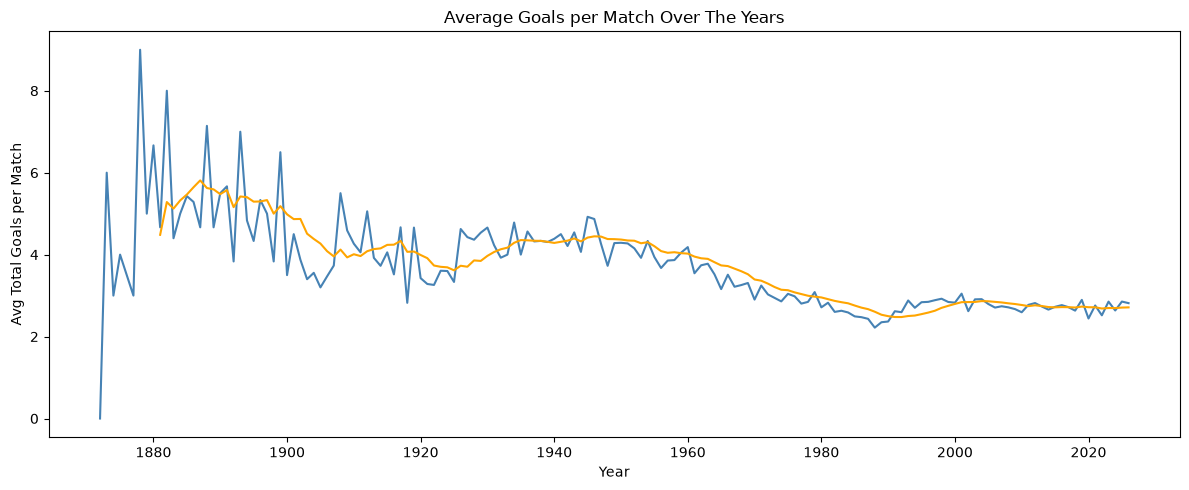

In [16]:
results = results.dropna(subset=['home_score', 'away_score']).copy()
results['date'] = pd.to_datetime(results['date'])
results['year'] = results['date'].dt.year

results['total_goals'] = results['home_score'] + results['away_score']

goals_per_year = results.groupby('year')['total_goals'].mean()

plt.figure(figsize=(12, 5))
plt.plot(goals_per_year.index, goals_per_year.values, color='steelblue')
plt.plot(goals_per_year.index, goals_per_year.rolling(10).mean(), color='orange', label='5-yr rolling avg')
plt.title('Average Goals per Match Over The Years')
plt.xlabel('Year')
plt.ylabel('Avg Total Goals per Match')
plt.tight_layout()
plt.show()

There seems to be a **downward** trend of goals scored per match since the 1940s.    
From around **4 goals scored per match to 2.5** in recent years.   
The first few years of international games in the late 1800s and early 1900s had a higher mean of goals scored per match and had alot more variation year on year.     
This could be due to a smaller sample size and also the game of football changing overtime to become more defensive and strategic.

2505
neutral
False    2220
True      285
Name: count, dtype: int64


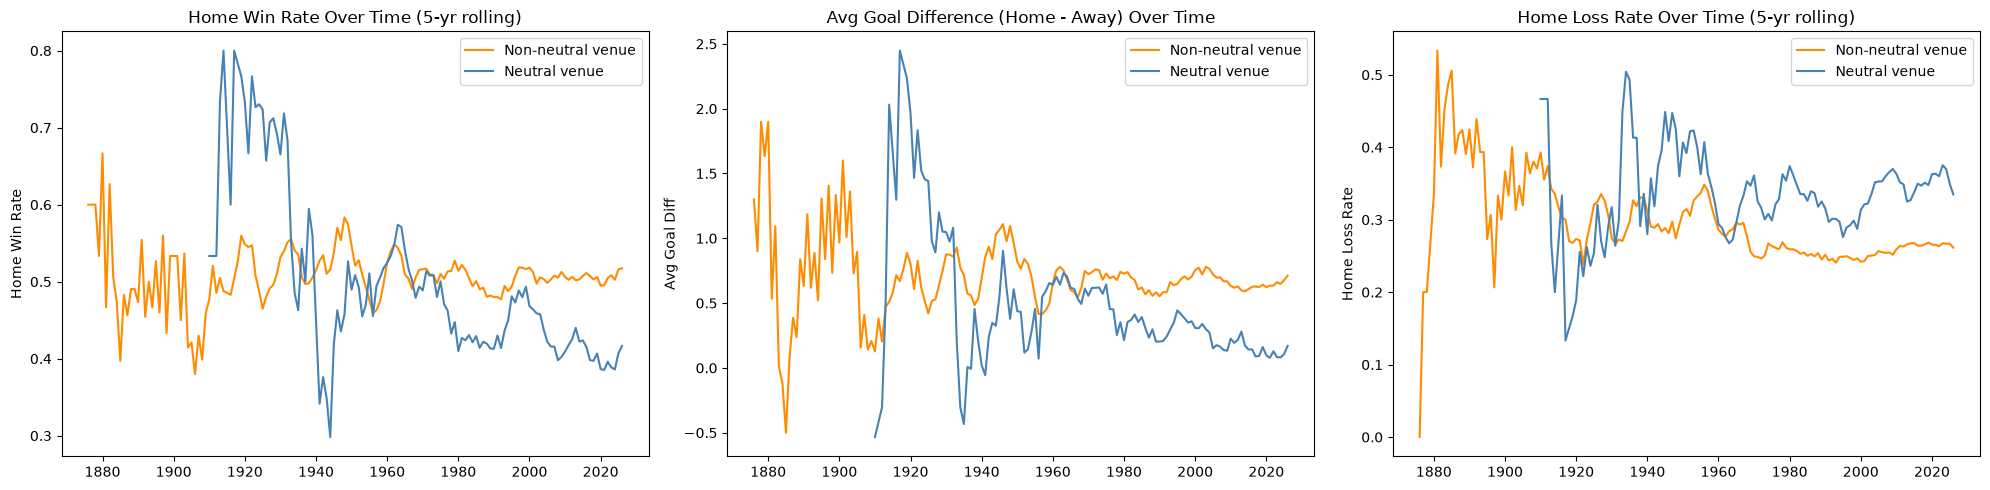

In [17]:
results['home_win'] = (results['home_score'] > results['away_score']).astype(int)
results['goal_diff'] = results['home_score'] - results['away_score']
results['home_loss'] = (results['home_score'] < results['away_score']).astype(int)

home_adv = results.groupby(['year', 'neutral']).agg(
    home_win_rate=('home_win', 'mean'),
    avg_goal_diff=('goal_diff', 'mean'),
    home_loss_rate=('home_loss', 'mean')  # <-- Added this line
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(20, 5)) 

for neutral_val, label, color in [(False, 'Non-neutral venue', 'darkorange'), (True, 'Neutral venue', 'steelblue')]:
    subset = home_adv[home_adv['neutral'] == neutral_val]
    axes[0].plot(subset['year'], subset['home_win_rate'].rolling(5).mean(), label=label, color=color)
    axes[1].plot(subset['year'], subset['avg_goal_diff'].rolling(5).mean(), label=label, color=color)
    axes[2].plot(subset['year'], subset['home_loss_rate'].rolling(5).mean(), label=label, color=color) 

axes[0].set_title('Home Win Rate Over Time (5-yr rolling)')
axes[0].set_ylabel('Home Win Rate')
axes[0].legend()

axes[1].set_title('Avg Goal Difference (Home - Away) Over Time')
axes[1].set_ylabel('Avg Goal Diff')
axes[1].legend()

axes[2].set_title('Home Loss Rate Over Time (5-yr rolling)')
axes[2].set_ylabel('Home Loss Rate')
axes[2].legend()

print(results[results['date'].dt.year < 1940].shape[0])
print(results[results['date'].dt.year < 1940]['neutral'].value_counts())

plt.tight_layout()
plt.show()


We can see that there is an advantage to the home team when playing at a non-neutral venue compared to playing at a neutral venue.   
However the advantage isn't so huge that it makes their winrate significantly greater than 0.5 but it is still very much a real advantage.   
The home team's loss rate is also lower therefore their draw rate is lower.  
    
Before 1940 there is only 2505 total games and only 285 of these were at neutral venues.   
The small sample size explains the spikes before 1940 for neutral games.   

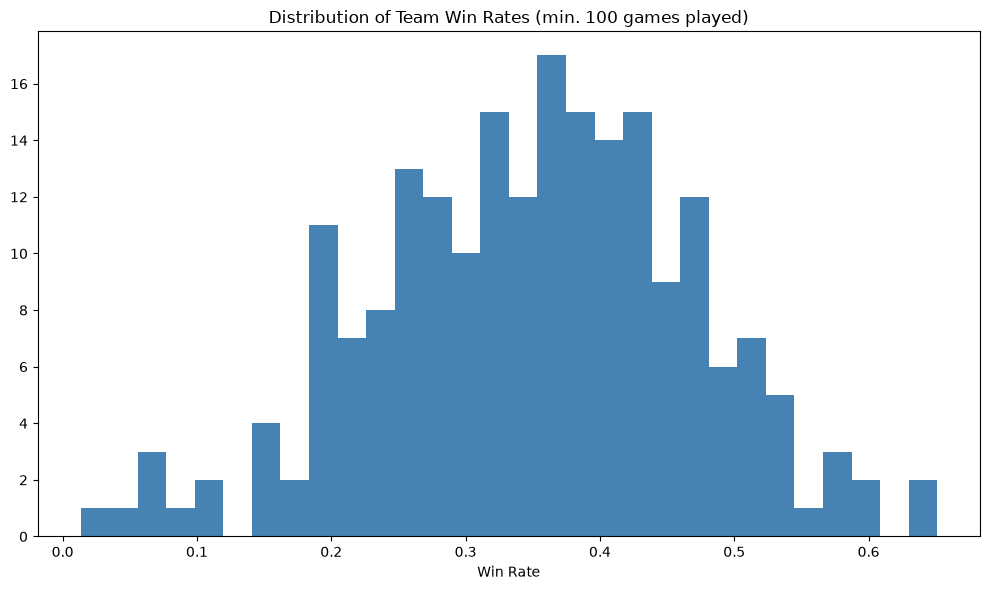

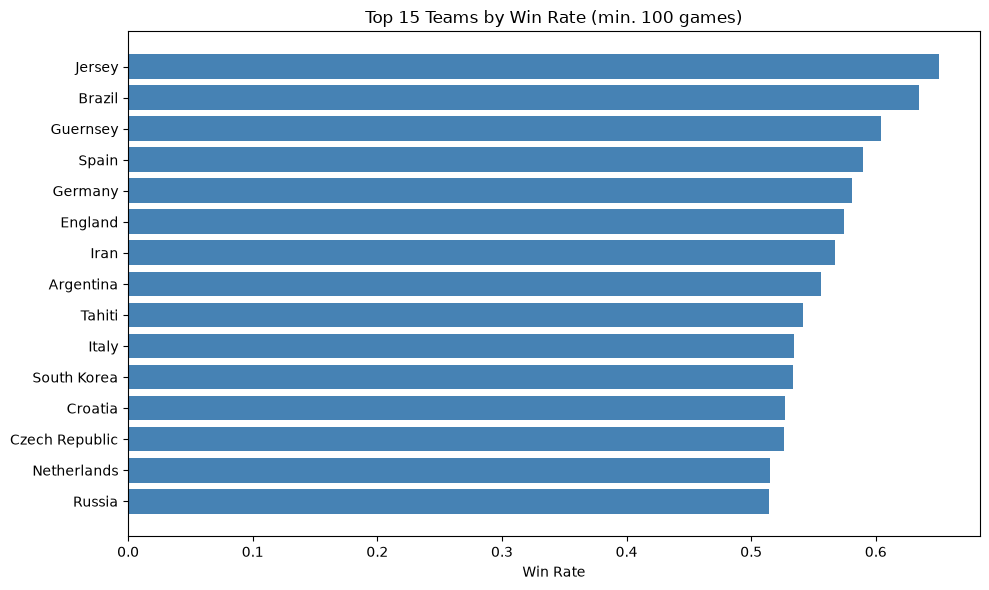

In [18]:
home_stats = results.groupby('home_team').agg(home_games=('home_win', 'count'), home_wins=('home_win', 'sum'))
results['away_win'] = (results['away_score'] > results['home_score']).astype(int)
away_stats = results.groupby('away_team').agg(away_games=('away_win', 'count'), away_wins=('away_win', 'sum'))

team_stats = home_stats.join(away_stats, how='outer').fillna(0)
team_stats['total_games'] = team_stats['home_games'] + team_stats['away_games']
team_stats['total_wins'] = team_stats['home_wins'] + team_stats['away_wins']
team_stats['win_rate'] = team_stats['total_wins'] / team_stats['total_games']

qualified = team_stats[team_stats['total_games'] >= 100].sort_values('win_rate', ascending=False)

plt.figure(figsize=(10, 6))
plt.hist(qualified['win_rate'], bins=30, color='steelblue')
plt.title('Distribution of Team Win Rates (min. 100 games played)')
plt.xlabel('Win Rate')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
top15 = qualified.head(15)
plt.barh(top15.index[::-1], top15['win_rate'][::-1], color='steelblue')
plt.title('Top 15 Teams by Win Rate (min. 100 games)')
plt.xlabel('Win Rate')
plt.tight_layout()
plt.show()

The winrate of most teams is approximately between 0.3 and 0.45    
We can see that Jersey has the highest win rate.   
However its important to note that this is for teams with a minimum of 100 games and also doesn't take into account the level of competition faced. As number of games increases the rankings do change.   
    
When training a prediction model it would be intuitive to create an ELO-ranking based system.   
This way all wins don't have the same weight.

In [19]:
def categorize_tournament(tournament_name):
    name = str(tournament_name).lower()

    if 'world cup' in name or 'copa américa' in name or 'euro' in name or 'nations cup' in name:
        if 'qualification' not in name and 'qualifying' not in name and 'qualifier' not in name:
            return 'Major Tournament'
    if 'qualification' in name or 'qualifying' in name or 'qor' in name or 'qualifier' in name:
        return 'Qualification'
    if 'friendly' in name:
        return 'Friendly'
    return 'Other / Regional Cup'

results['tournament_type'] = results['tournament'].apply(categorize_tournament)

print(len(results['tournament_type']))
print(results['tournament_type'].value_counts())

49501
tournament_type
Friendly                18388
Qualification           15928
Other / Regional Cup    12468
Major Tournament         2717
Name: count, dtype: int64


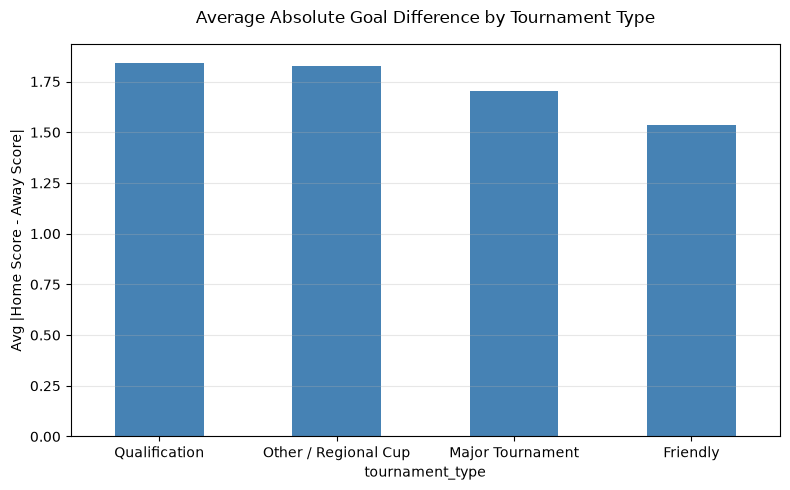

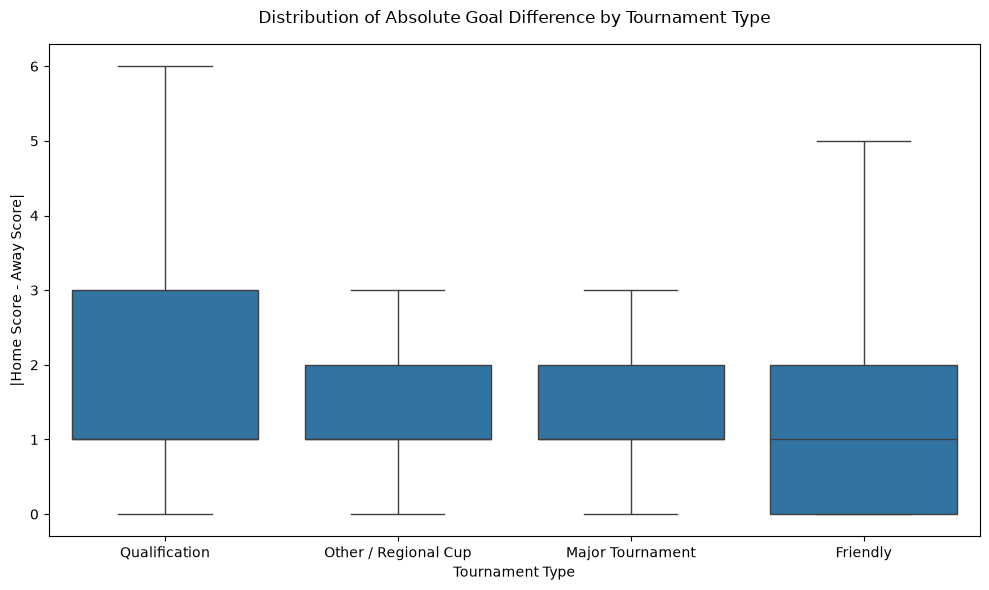

In [20]:
results["abs_goal_diff"] = (
    results["home_score"] - results["away_score"]
).abs()

avg_diff_by_type = (
    results.groupby("tournament_type")["abs_goal_diff"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))
avg_diff_by_type.plot(kind="bar", color="steelblue")
plt.title("Average Absolute Goal Difference by Tournament Type", pad=15)
plt.ylabel("Avg |Home Score - Away Score|")
plt.grid(True, axis="y", linestyle="-", alpha=0.3)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=results, x="tournament_type", y="abs_goal_diff", showfliers=False,
    order=avg_diff_by_type.index
)

plt.title("Distribution of Absolute Goal Difference by Tournament Type", pad=15)
plt.xlabel("Tournament Type")
plt.ylabel("|Home Score - Away Score|")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Here we can see the the average difference in goals between teams is quite similar for the different types of tournaments.   
However its important to note that there seems to be a larger inter-quartile range and more outliers for friendly games and qualifiers in comparison to Major tournaments and other games.   
This could be due to more competitive games in major tournaments. 

### Summary of Exploration & Modeling Approach

**Key Findings**
- The dataset is clean overall — 49,505 matches, no duplicates, and only 4 null values corresponding to unplayed 2026 World Cup fixtures (not missing data).
- Average goals per match have declined steadily since the 1940s (from ~4 to ~2.5 today), suggesting the game has become more tactical/defensive over time. This makes recency an important factor for a modern prediction task.
- Home advantage is real but moderate — teams playing at non-neutral venues have a higher win rate and lower loss rate than at neutral venues.
- Raw win rate is a poor measure of team strength since it doesn't account for opponent quality — a team with a high win rate against weak opposition isn't directly comparable to one that beat strong teams. This motivates an Elo-style rating system over simple win/loss statistics.
- Absolute goal difference varies by tournament type, with wider spreads in friendlies and qualifiers compared to major tournaments. This suggests tournament importance should influence how strongly a result impacts a team's rating.

**Chosen Approach**
- Calculate Elo ratings using the **full historical dataset** (1872–present), incorporating a home advantage adjustment and a tournament-weighted K-factor, so that ratings are properly established by the time they're used for modern predictions.
- Restrict the **model training data** to the last 15 years, using each team's Elo rating as of the match date alongside other engineered features
- This separation balances using the full depth of historical results to build accurate ratings, while training the predictive model itself on data that reflects how football is played today.

In [21]:
is_chronological = results['date'].is_monotonic_increasing
print(f"Is the dataset perfectly ordered? {is_chronological}")

df = results

running_max_date = df['date'].cummax()

# A row is broken if its date is strictly earlier than the max date seen before it
out_of_order_mask = df['date'] < running_max_date

# Display the rows that are out of order
out_of_order_matches = df[out_of_order_mask]
print(f"Found {len(out_of_order_matches)} out-of-order matches:")
display(out_of_order_matches[['date', 'home_team', 'away_team']])

print(results[49305:49309])

Is the dataset perfectly ordered? False
Found 1 out-of-order matches:


,date,home_team,away_team
49307,2026-06-01,Maldives,Pakistan


            date    home_team      away_team  home_score  away_score  \
49305 2026-06-03       Poland        Nigeria         2.0         2.0   
49306 2026-06-03  Philippines           Guam         5.0         1.0   
49307 2026-06-01     Maldives       Pakistan         0.0         3.0   
49308 2026-06-04      Andorra  Liechtenstein         2.0         0.0   

                                              tournament    city      country  \
49305                                           Friendly  Warsaw       Poland   
49306                                           Friendly  Manila  Philippines   
49307  Diamond Jubilee International Football Tournament    Malé     Maldives   
49308                                           Friendly  Encamp      Andorra   

       neutral  year  total_goals  home_win  goal_diff  home_loss  away_win  \
49305    False  2026          4.0         0        0.0          0         0   
49306    False  2026          6.0         1        4.0          0         0

During feature engineering stage I noticed this in the dataset.   
The date for Maldives vs Pakistan is incorrect.    
It should be the 4th of June 2026.